# Lab 06

Nguyễn Phúc Minh Châu - 22302421

In [1]:
#install missing libraries
%pip install yfinance

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 949.2/949.2 kB 5.4 MB/s  0:00:00eta 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 7.1 MB/s  0:00:01 eta 0:00:01
  DEPRECATION: Building 'multitasking' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'multitasking'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15636 sha256=377ecdf66cd9a9d35ca977a2ce74c991f3f277a735d11bc034ad2dde35b5966b
  Stored in direct

In [1]:
#import libraries
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

In [97]:
# --- Define tickers and time range ---
tickers = ['AAPL', 'MSFT', 'NVDA']
start_date = '2025-08-01'
end_date = '2025-08-31'

#download the data
download = yf.download(tickers, start=start_date, end=end_date)
data = {col: download['Close'][col].to_numpy() for col in download['Close'].columns}
dates = np.array(download.index.values).astype('datetime64[D]').astype(int) % 100  # Extract day of month 

/tmp/ipykernel_46153/54575424.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  download = yf.download(tickers, start=start_date, end=end_date)
[*********************100%***********************]  3 of 3 completed


In [77]:
download.head()

Price            Close                                High              \
Ticker            AAPL        MSFT        NVDA        AAPL        MSFT   
Date                                                                     
2025-08-01  202.150589  523.249817  173.710205  213.337890  534.920634   
2025-08-04  203.119492  534.760925  179.989853  207.644355  537.366627   
2025-08-05  202.689957  526.883850  178.249939  205.107211  536.418164   
2025-08-06  213.008255  524.078491  179.409882  215.135845  530.827407   
2025-08-07  219.780563  519.985229  180.759811  220.599641  527.223331   

Price                          Low                                Open  \
Ticker            NVDA        AAPL        MSFT        NVDA        AAPL   
Date                                                                     
2025-08-01  176.530038  201.271582  520.005151  170.880363  210.630955   
2025-08-04  180.189839  201.451371  527.263241  174.510166  204.278165   
2025-08-05  180.249826  201.930824  526.374677  175.890071  203.169408   
2025-08-06  179.889850  205.356935  523.170011  176.240062  205.396898   
2025-08-07  183.869637  216.334477  516.700590  178.789921  218.631873   

Price                                  Volume                       
Ticker            MSFT        NVDA       AAPL      MSFT       NVDA  
Date                                                                
2025-08-01  534.121959  174.080179  104434500  28977600  204529000  
2025-08-04  527.403026  175.150129   75109300  25349000  148174600  
2025-08-05  536.298366  179.609863   44155100  19171600  156407600  
2025-08-06  530.028732  176.320059  108483100  21355700  137192300  
2025-08-07  525.935409  181.559769   90224800  16079100  151878400

In [98]:
data

{'AAPL': array([202.15058899, 203.11949158, 202.68995667, 213.008255  ,
        219.78056335, 229.0900116 , 227.17999268, 229.6499939 ,
        233.33000183, 232.77999878, 231.58999634, 230.88999939,
        230.55999756, 226.00999451, 224.8999939 , 227.75999451,
        227.16000366, 229.30999756, 230.49000549, 232.55999756,
        232.13999939]),
 'MSFT': array([523.24981689, 534.76092529, 526.8838501 , 524.07849121,
        519.98522949, 521.18322754, 520.91369629, 528.37139893,
        519.72564697, 521.62249756, 519.31628418, 516.25128174,
        508.93334961, 504.89001465, 504.23999023, 507.23001099,
        504.26000977, 502.04000854, 506.73999023, 509.64001465,
        506.69000244]),
 'NVDA': array([173.71020508, 179.98985291, 178.24993896, 179.40988159,
        180.7598114 , 182.68969727, 182.04972839, 183.14967346,
        181.57975769, 182.00973511, 180.43981934, 181.99972534,
        175.63009644, 175.3901062 , 174.97012329, 177.97996521,
        179.79986572, 181.759750

In [109]:
dates

array([ 1,  4,  5,  6,  7,  8, 11, 12, 13, 14, 15, 18, 19, 20, 21, 22, 25,
       26, 27, 28, 29])

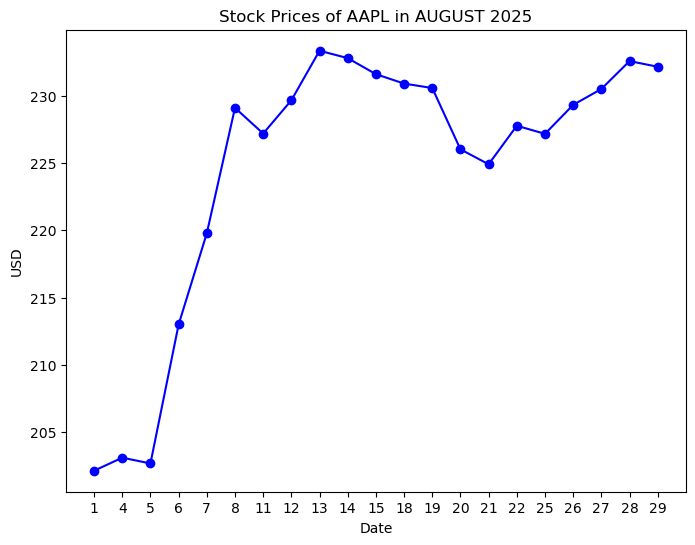

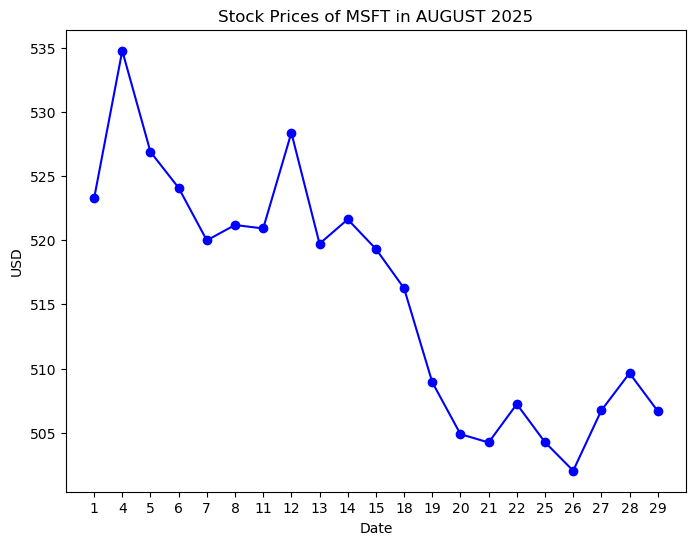

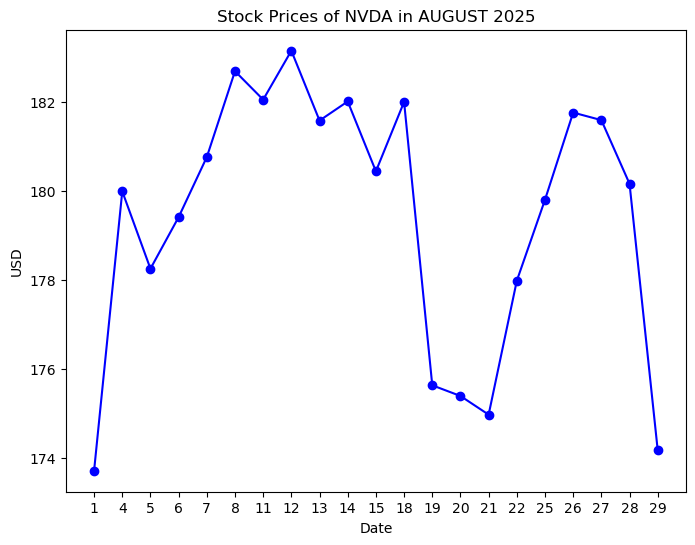

In [118]:
# --- Chart 1: Line chart for stock price ---
for ticker in tickers:
    plt.figure(figsize=(8, 6))
    x = range(len(dates))
    plt.plot(
        x, 
        data[ticker],
        label=ticker, 
        color='blue', 
        marker='o'
    )

    plt.xticks(x, [str(d)[-2:] for d in dates])

    plt.xlabel('Date')
    plt.ylabel('USD')
    plt.title(f'Stock Prices of {ticker} in AUGUST 2025')
    plt.show()


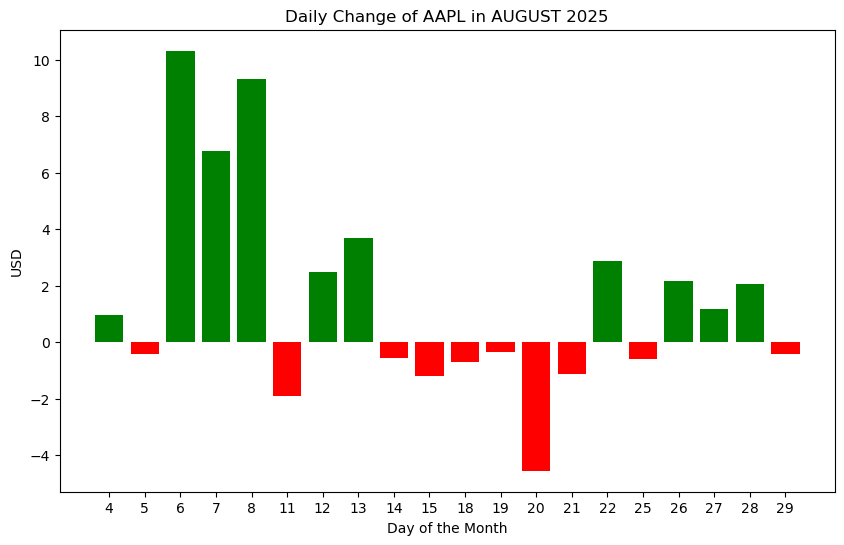

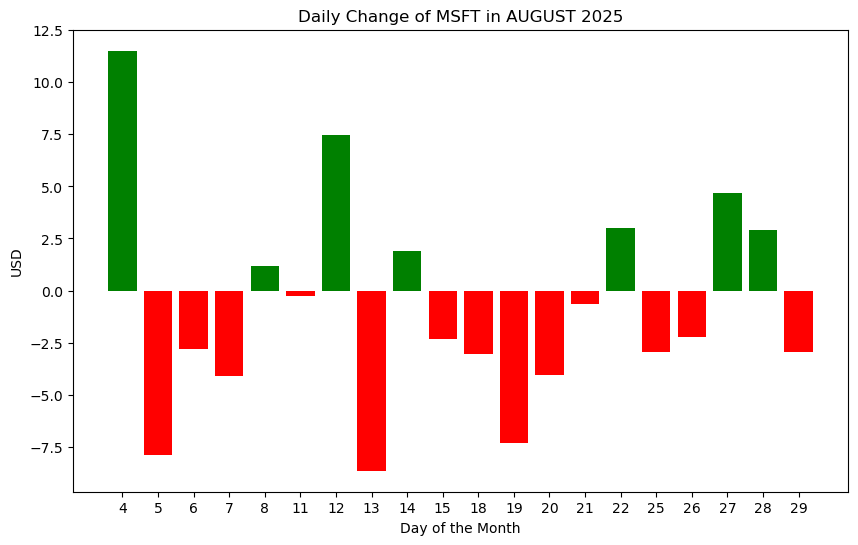

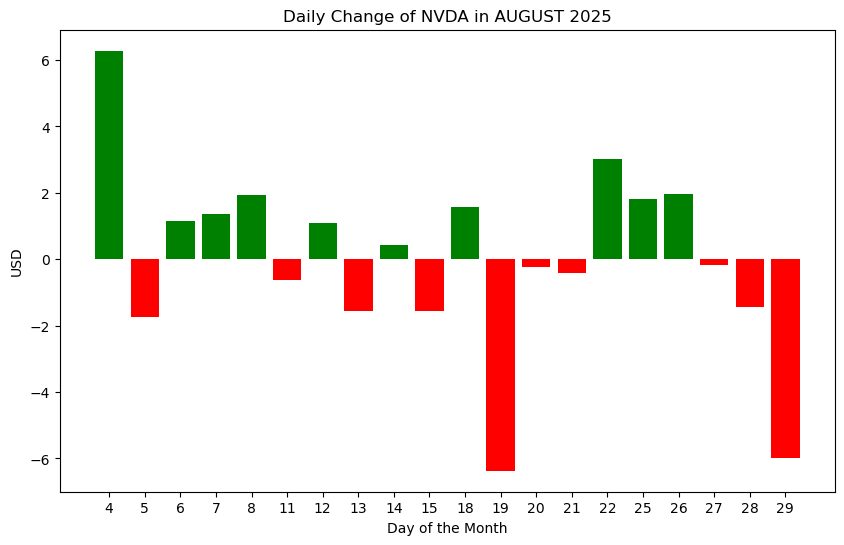

In [ ]:
# --- Chart 2: Bar chart for daily change ---
for ticker in tickers:
    prices = data[ticker]
    changes = np.diff(prices)
    x_dates = dates[1:]

    colors = np.where(changes >= 0, 'green', 'red')

    plt.figure(figsize=(10, 6))
    plt.bar(range(len(changes)), changes, color=colors)

    plt.xticks(range(len(changes)), [str(d)[-2:] for d in x_dates])

    plt.xlabel('Day of the Month')
    plt.ylabel('USD')
    plt.title(f'Daily Change of {ticker} in AUGUST 2025')
    plt.show()

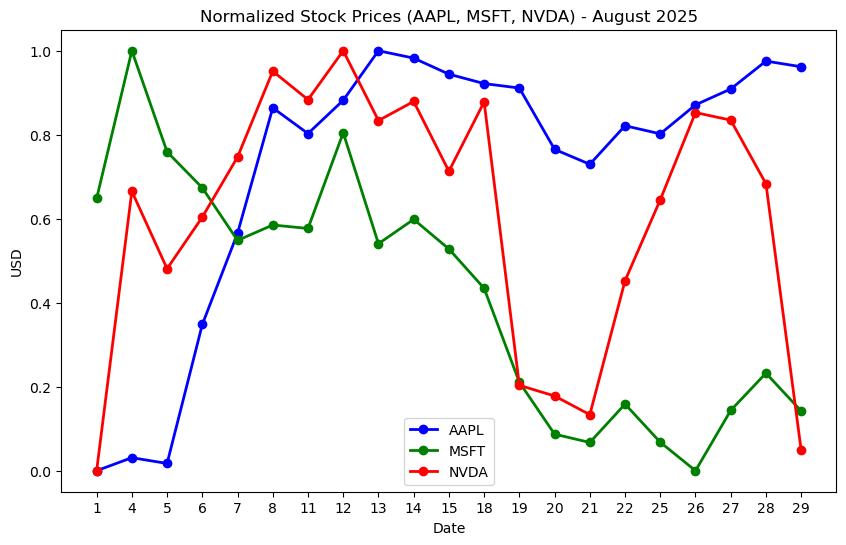

In [123]:
# --- Chart 3: Combined line chart with normalized prices ---
plt.figure(figsize=(10, 6))

colors = ['blue', 'green', 'red']

x = range(len(dates))

for i, ticker in enumerate(tickers):
    prices = data[ticker]
    # scale [0, 1]
    norm = (prices - np.min(prices)) / (np.max(prices) - np.min(prices))
    
    plt.plot(
        x, norm,
        label=ticker,
        color=colors[i],
        marker='o',
        linewidth=2
    )

plt.xticks(x, [str(d)[-2:] for d in dates])
plt.xlabel('Date')
plt.ylabel('USD')
plt.title('Normalized Stock Prices (AAPL, MSFT, NVDA) - August 2025')
plt.legend()
plt.show()